### Baseline model training

Let's train a model using our baseline setup plus label smoothing, using no other regularization techniques. My baseline network contains 3 hidden layers and 128 hidden units with ReLU activation function. I use the Adam optimiser with a learning rate of 10−4.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import logging
# import sys
# sys.path.append('/path/to/mlpractical')

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser
from mlp.train_model_and_plot_stats import train_model_and_plot_stats

In [6]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng, smooth_labels=False)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng, smooth_labels=False)

KeysView(NpzFile '/Users/hallaei/UoE/mlp/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/hallaei/UoE/mlp/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


In [7]:
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1: 3.1s to complete
    error(train)=1.32e+00, acc(train)=6.31e-01, error(valid)=1.33e+00, acc(valid)=6.24e-01
Epoch 10: 2.5s to complete
    error(train)=6.32e-01, acc(train)=8.05e-01, error(valid)=6.66e-01, acc(valid)=7.94e-01
Epoch 20: 2.5s to complete
    error(train)=4.88e-01, acc(train)=8.41e-01, error(valid)=5.52e-01, acc(valid)=8.22e-01
Epoch 30: 2.7s to complete
    error(train)=4.20e-01, acc(train)=8.59e-01, error(valid)=5.11e-01, acc(valid)=8.33e-01
Epoch 40: 2.2s to complete
    error(train)=3.71e-01, acc(train)=8.74e-01, error(valid)=4.91e-01, acc(valid)=8.40e-01
Epoch 50: 2.1s to complete
    error(train)=3.42e-01, acc(train)=8.83e-01, error(valid)=4.87e-01, acc(valid)=8.39e-01
Epoch 60: 2.9s to complete
    error(train)=3.11e-01, acc(train)=8.93e-01, error(valid)=4.82e-01, acc(valid)=8.42e-01
Epoch 70: 2.5s to complete
    error(train)=2.95e-01, acc(train)=8.96e-01, error(valid)=4.89e-01, acc(valid)=8.41e-01
Epoch 80: 2.1s to complete
    error(train)=2.71e-01, acc

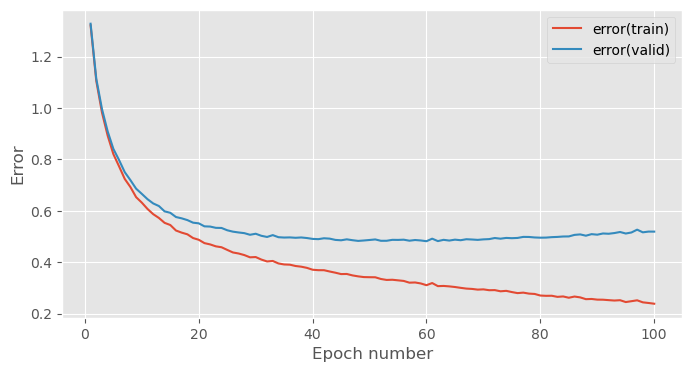

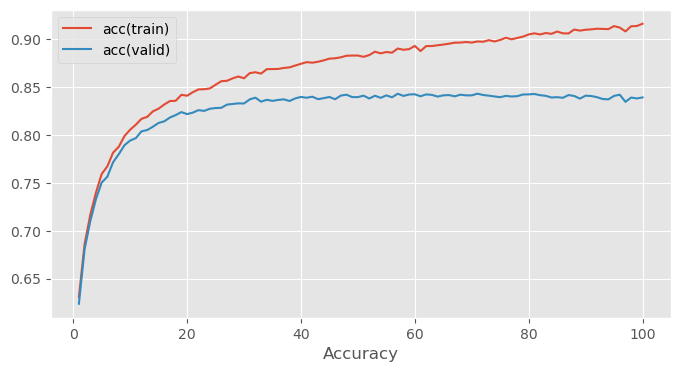

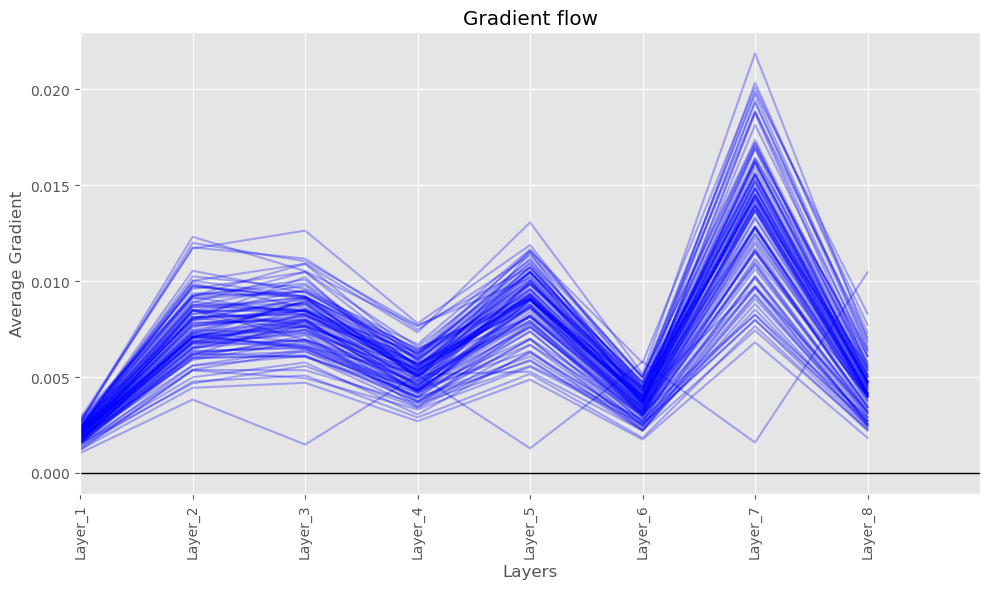

In [8]:
# Create model with three hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    ReluLayer(), 
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)